# WCDA Daily Analysis

这个 notebook 用于 **Mkn421** 的 WCDA daily light curve 基础时序分析，输入数据为
`data/LHAASO-WCDA_Mkn421_2025-03-29_2026-03-29_day.csv`。

分析范围保持与 weekly 主模板一致：只看真实观测数据上的 light curve、Morlet CWT 和 WWZ，
不做模拟光变、Monte Carlo 或显著性检验。


## 1. 导入依赖与路径定位


In [1]:
from pathlib import Path
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pycwt as wavelet
from scipy.signal import find_peaks
from libwwz import wwt


def locate_project_root(markers=("data", "notebooks", "src")):
    # 从当前工作目录向上回溯，找到仓库根目录。
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise FileNotFoundError(f"Could not locate project root from {cwd}")


PROJECT_ROOT = locate_project_root()
DATA_ROOT = PROJECT_ROOT / "data"
NOTEBOOK_ROOT = PROJECT_ROOT / "notebooks"

plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
})

print("PROJECT_ROOT =", PROJECT_ROOT)


PROJECT_ROOT = /mnt/mydisk/server/projects/QPO


## 2. 数据加载

这里直接读取 daily CSV，并确认列名、行数和时间范围。


In [2]:
WCDA_CSV = DATA_ROOT / 'LHAASO-WCDA_Mkn421_2025-03-29_2026-03-29_day.csv'
if not WCDA_CSV.exists():
    raise FileNotFoundError(f'Could not locate the WCDA daily CSV: {WCDA_CSV}')

df_wcda_raw = pd.read_csv(WCDA_CSV, comment='#')
df_wcda_raw.columns = [col.strip() for col in df_wcda_raw.columns]

print('WCDA_CSV =', WCDA_CSV)
print('rows =', len(df_wcda_raw))
print('columns =', list(df_wcda_raw.columns))
print('raw MJD range =', df_wcda_raw['mjd'].dropna().min(), '->', df_wcda_raw['mjd'].dropna().max())
df_wcda_raw.head()


WCDA_CSV = /mnt/mydisk/server/projects/QPO/data/LHAASO-WCDA_Mkn421_2025-03-29_2026-03-29_day.csv
rows = 366
columns = ['name', 'mjd', 'n_on', 'n_bkg', 'n_off', 'tobs']
raw MJD range = 60763.16682997689 -> 61128.16676400474


,name,mjd,n_on,n_bkg,n_off,tobs
0,2025-03-29_2025-03-29,60763.166830,"[6357.0, 776.0, 65.0, 5.0, 2.0, 0.0, 0.0]","[6133.179827500402, 714.7071027024954, 71.8253...","[11083235.065138819, 1290980.8021814928, 12950...",29131.0
1,2025-03-30_2025-03-30,60764.166840,"[6122.0, 729.0, 74.0, 3.0, 3.0, 0.0, 0.0]","[6019.680736484169, 703.8677688211202, 69.6616...","[10920900.076493055, 1275210.4018196883, 12617...",29155.1
2,2025-03-31_2025-03-31,60765.166903,"[6073.0, 754.0, 93.0, 4.0, 1.0, 0.0, 0.0]","[6068.543949258288, 707.8509258419547, 70.3215...","[10982360.04753816, 1278727.7089996836, 126998...",29121.2
3,2025-04-01_2025-04-01,60766.166938,"[6080.0, 737.0, 92.0, 7.0, 2.0, 0.0, 0.0]","[6069.271399877339, 712.8750946010748, 71.2371...","[10973264.351678034, 1288412.7492602062, 12863...",29069.6
4,2025-04-02_2025-04-02,60767.166752,"[6026.0, 728.0, 80.0, 5.0, 2.0, 1.0, 0.0]","[6004.763677778811, 705.5907082330218, 72.1125...","[10838081.386560952, 1273752.6727527562, 12962...",29084.9


## 3. 数据预处理

把 `n_on`、`n_bkg`、`n_off` 从字符串列表转成数组，计算 excess rate 和误差。
这份 daily 数据中有 3 个显式缺失日（`2025-09-12` 到 `2025-09-14`），另有 3 个 `tobs=0` 的零曝光 bin。
这里不补值、不插值，只在后续通过有效性筛选自然排除。


In [3]:
def parse_array_column(value):
    if pd.isna(value) or value in ('', 'None'):
        return None
    values = ast.literal_eval(value)
    return np.asarray(values, dtype=float)


df_wcda = df_wcda_raw.copy()
for col in ['n_on', 'n_bkg', 'n_off']:
    df_wcda[col] = df_wcda[col].apply(parse_array_column)


def compute_wcda_products(row):
    n_on = row['n_on']
    n_bkg = row['n_bkg']
    n_off = row['n_off']
    tobs = row['tobs']

    if n_on is None or n_bkg is None or n_off is None or pd.isna(tobs):
        return pd.Series({
            'excess_counts': np.nan,
            'flux_excess': np.nan,
            'flux_excess_err': np.nan,
            'n_on_tot': np.nan,
            'n_bkg_tot': np.nan,
        })

    tobs = float(tobs)
    if not np.isfinite(tobs) or tobs <= 0:
        return pd.Series({
            'excess_counts': np.nan,
            'flux_excess': np.nan,
            'flux_excess_err': np.nan,
            'n_on_tot': np.nan,
            'n_bkg_tot': np.nan,
        })

    excess = n_on - n_bkg
    excess_counts = float(np.sum(excess))
    flux_excess = excess_counts / tobs

    alpha = np.divide(n_bkg, n_off, out=np.zeros_like(n_bkg, dtype=float), where=n_off > 0)
    sigma_bin = np.sqrt(np.clip(n_on + np.square(alpha) * n_off, 0.0, None))
    flux_excess_err = float(np.sqrt(np.sum(np.square(sigma_bin))) / tobs)

    return pd.Series({
        'excess_counts': excess_counts,
        'flux_excess': flux_excess,
        'flux_excess_err': flux_excess_err,
        'n_on_tot': float(np.sum(n_on)),
        'n_bkg_tot': float(np.sum(n_bkg)),
    })


df_wcda = df_wcda.join(df_wcda.apply(compute_wcda_products, axis=1))
df_wcda = df_wcda.sort_values('mjd').reset_index(drop=True)

missing_mask = (
    df_wcda['mjd'].isna()
    | df_wcda['tobs'].isna()
    | df_wcda['flux_excess'].isna()
    | df_wcda['flux_excess_err'].isna()
)
missing_rows = df_wcda.loc[missing_mask, ['name', 'mjd', 'tobs']].copy()

valid_mask = (
    np.isfinite(df_wcda['mjd'])
    & np.isfinite(df_wcda['flux_excess'])
    & np.isfinite(df_wcda['flux_excess_err'])
    & np.isfinite(df_wcda['tobs'])
    & (df_wcda['tobs'] > 0)
    & (df_wcda['flux_excess_err'] > 0)
)
df_wcda = df_wcda.loc[valid_mask].copy().reset_index(drop=True)

t_wcda = df_wcda['mjd'].to_numpy(dtype=float)
flux_wcda = df_wcda['flux_excess'].to_numpy(dtype=float)
flux_err_wcda = df_wcda['flux_excess_err'].to_numpy(dtype=float)

print('missing daily bins =', len(missing_rows))
print(missing_rows.to_string(index=False))
print('usable points =', len(df_wcda))
print('final MJD range =', float(t_wcda.min()), '->', float(t_wcda.max()))
print('median cadence [day] =', float(np.median(np.diff(t_wcda))))
df_wcda[['name', 'mjd', 'excess_counts', 'flux_excess', 'flux_excess_err']].head()


missing daily bins = 6
                 name          mjd  tobs
2025-07-25_2025-07-25 60880.750392   0.0
2025-09-06_2025-09-06 60924.166672   0.0
2025-09-11_2025-09-11 60928.750442   0.0
2025-09-12_2025-09-12          NaN   NaN
2025-09-13_2025-09-13          NaN   NaN
2025-09-14_2025-09-14          NaN   NaN
usable points = 360
final MJD range = 60763.16682997689 -> 61128.16676400474
median cadence [day] = 0.9999995372418198


,name,mjd,excess_counts,flux_excess,flux_excess_err
0,2025-03-29_2025-03-29,60763.166830,279.550054,0.009596,0.002915
1,2025-03-30_2025-03-30,60764.166840,131.687893,0.004517,0.002856
2,2025-03-31_2025-03-31,60765.166903,72.533270,0.002491,0.002858
3,2025-04-01_2025-04-01,60766.166938,58.337321,0.002007,0.002862
4,2025-04-02_2025-04-02,60767.166752,53.764394,0.001849,0.002845


## 4. 光变可视化

先画出原始 daily 光变，直观看一下时间覆盖、短时波动和缺口位置。


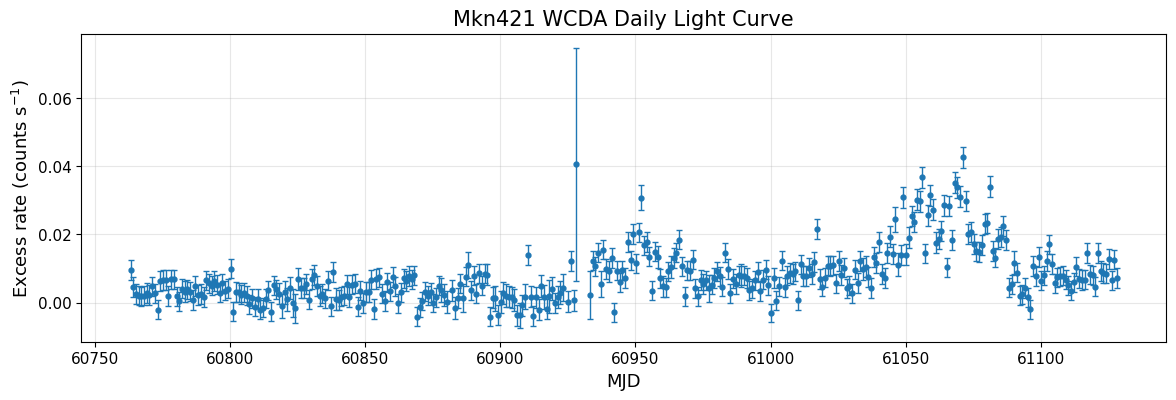

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.errorbar(
    t_wcda,
    flux_wcda,
    yerr=flux_err_wcda,
    fmt='o',
    ms=3.5,
    capsize=2,
    elinewidth=1,
)
ax.set_xlabel('MJD')
ax.set_ylabel('Excess rate (counts s$^{-1}$)')
ax.set_title('Mkn421 WCDA Daily Light Curve')
plt.show()


## 5. CWT 分析

这里用 Morlet 小波看时-频局部结构，并提取 Global Wavelet Spectrum 作为全局参考。
对 daily 数据，周期搜索范围改为 **5–200 天**，以匹配约 1 天 cadence 和约 1 年总时长。


In [5]:
def standardize_flux(flux):
    flux = np.asarray(flux, dtype=float)
    flux = flux - np.nanmean(flux)
    std = np.nanstd(flux)
    if not np.isfinite(std) or std == 0:
        raise ValueError('Flux standard deviation is zero or non-finite.')
    return flux / std


def run_cwt(t_mjd, flux, *, dj=1/12, period_min=5.0, period_max=200.0, mother=None):
    t_mjd = np.asarray(t_mjd, dtype=float)
    flux = np.asarray(flux, dtype=float)
    dt = float(np.median(np.diff(t_mjd)))
    if mother is None:
        mother = wavelet.Morlet(6)
    s0 = 2.0 * dt
    J = int(np.log2(len(flux) * dt / s0) / dj)

    y = standardize_flux(flux)
    wave, scales, freqs, coi, fft, fftfreqs = wavelet.cwt(
        y,
        dt,
        dj=dj,
        s0=s0,
        J=J,
        wavelet=mother,
    )
    power = np.abs(wave) ** 2
    period = 1.0 / freqs
    gws = np.nanmean(power, axis=1)
    mask_period = (period >= period_min) & (period <= period_max)

    return {
        'dt': dt,
        'dj': dj,
        'mother': mother,
        's0': s0,
        'J': J,
        'power': power,
        'period': period,
        'coi': np.asarray(coi, dtype=float),
        'gws': gws,
        'mask_period': mask_period,
        'period_min': period_min,
        'period_max': period_max,
    }


def plot_cwt_summary(t_mjd, flux, flux_err, result, *, lc_title, flux_label):
    t_mjd = np.asarray(t_mjd, dtype=float)
    flux = np.asarray(flux, dtype=float)
    flux_err = None if flux_err is None else np.asarray(flux_err, dtype=float)

    period = result['period']
    mask_period = result['mask_period']
    power = result['power']
    coi = result['coi']
    gws = result['gws']
    period_min = result['period_min']
    period_max = result['period_max']
    T, P = np.meshgrid(t_mjd, period)

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(17, 4.8),
        gridspec_kw={'width_ratios': [1.45, 2.5, 1.0]},
        constrained_layout=True,
    )

    ax_lc, ax_map, ax_gws = axes
    if flux_err is not None:
        ax_lc.errorbar(t_mjd, flux, yerr=flux_err, fmt='o', ms=3.5, capsize=2, elinewidth=1)
    else:
        ax_lc.plot(t_mjd, flux, 'o-', ms=3.5, lw=1.2)
    ax_lc.set_title(lc_title)
    ax_lc.set_xlabel('MJD')
    ax_lc.set_ylabel(flux_label)

    im = ax_map.contourf(
        T[mask_period, :],
        P[mask_period, :],
        power[mask_period, :],
        levels=50,
        cmap='magma',
        extend='both',
    )
    coi_clip = np.clip(coi, period_min, period_max)
    ax_map.fill_between(
        t_mjd,
        period_max,
        coi_clip,
        where=coi_clip <= period_max,
        color='white',
        alpha=0.5,
        hatch='/',
        edgecolor='0.7',
        linewidth=0.0,
    )
    ax_map.plot(t_mjd, coi_clip, color='white', lw=1.5, label='COI')
    ax_map.set_yscale('log')
    ax_map.set_ylim(period_min, period_max)
    ax_map.set_xlabel('MJD')
    ax_map.set_ylabel('Period (day)')
    ax_map.set_title('CWT Power Spectrum (Morlet)')
    ax_map.legend(loc='upper right')
    cbar = fig.colorbar(im, ax=ax_map, pad=0.02)
    cbar.set_label('Power')

    ax_gws.plot(gws[mask_period], period[mask_period], color='black', lw=1.6)
    ax_gws.set_xscale('log')
    ax_gws.set_yscale('log')
    ax_gws.set_ylim(period_min, period_max)
    ax_gws.set_xlabel('Global Wavelet Power')
    ax_gws.set_title('Global Wavelet Spectrum')
    plt.setp(ax_gws.get_yticklabels(), visible=False)

    return fig, axes


def clean_and_merge_weighted(t, y, yerr):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    yerr = np.asarray(yerr, dtype=float)

    mask = np.isfinite(t) & np.isfinite(y) & np.isfinite(yerr) & (yerr > 0)
    t, y, yerr = t[mask], y[mask], yerr[mask]

    order = np.argsort(t)
    t, y, yerr = t[order], y[order], yerr[order]

    uniq_t, idx_start = np.unique(t, return_index=True)
    if len(uniq_t) == len(t):
        return t, y, yerr

    y_new = np.empty_like(uniq_t, dtype=float)
    e_new = np.empty_like(uniq_t, dtype=float)
    for k, _ in enumerate(uniq_t):
        i0 = idx_start[k]
        i1 = idx_start[k + 1] if (k + 1 < len(uniq_t)) else len(t)
        w = 1.0 / np.square(yerr[i0:i1])
        y_new[k] = np.sum(w * y[i0:i1]) / np.sum(w)
        e_new[k] = np.sqrt(1.0 / np.sum(w))
    return uniq_t, y_new, e_new


def run_wwz(t_mjd, flux, flux_err, *, period_min=5.0, period_max=200.0, time_divisions=250, decay_constant=0.0125):
    t, y, yerr = clean_and_merge_weighted(t_mjd, flux, flux_err)
    t_span = float(t.max() - t.min())
    freq_low = 1.0 / period_max
    freq_high = 1.0 / period_min
    freq_step = 0.05 / t_span

    tau_mat, freq_mat, wwz_mat, amp_mat, coef_mat, neff_mat = wwt(
        timestamps=t.astype(float),
        magnitudes=y.astype(float),
        time_divisions=time_divisions,
        freq_params=[freq_low, freq_high, freq_step, True],
        decay_constant=decay_constant,
        method='linear',
        parallel=True,
    )

    period_mat = 1.0 / freq_mat
    ridge_idx = np.argmax(wwz_mat, axis=1)
    ridge_tau = tau_mat[:, 0]
    ridge_period = period_mat[np.arange(len(ridge_idx)), ridge_idx]
    ridge_power = wwz_mat[np.arange(len(ridge_idx)), ridge_idx]
    global_wwz = np.nanmean(wwz_mat, axis=0)
    period_axis = 1.0 / freq_mat[0, :]

    return {
        't': t,
        'y': y,
        'yerr': yerr,
        't_span': t_span,
        'freq_low': freq_low,
        'freq_high': freq_high,
        'freq_step': freq_step,
        'time_divisions': time_divisions,
        'decay_constant': decay_constant,
        'tau_mat': tau_mat,
        'freq_mat': freq_mat,
        'period_mat': period_mat,
        'wwz_mat': wwz_mat,
        'ridge_tau': ridge_tau,
        'ridge_period': ridge_period,
        'ridge_power': ridge_power,
        'global_wwz': global_wwz,
        'period_axis': period_axis,
        'period_min': period_min,
        'period_max': period_max,
    }


def plot_wwz_summary(result, *, lc_title, flux_label):
    t = result['t']
    y = result['y']
    yerr = result['yerr']
    period_min = result['period_min']
    period_max = result['period_max']

    tau_plot = result['tau_mat'][:, 0]
    period_mat = result['period_mat']
    wwz_mat = result['wwz_mat']
    sort_idx = np.argsort(period_mat[0, :])
    p_axis = period_mat[0, sort_idx]
    wwz_plot = wwz_mat[:, sort_idx]

    period_axis = result['period_axis']
    global_wwz = result['global_wwz']
    period_sort = np.argsort(period_axis)

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(17, 4.8),
        gridspec_kw={'width_ratios': [1.45, 2.5, 1.0]},
        constrained_layout=True,
    )
    ax_lc, ax_map, ax_gwwz = axes

    ax_lc.errorbar(t, y, yerr=yerr, fmt='o', ms=3.5, capsize=2, elinewidth=1)
    ax_lc.set_title(lc_title)
    ax_lc.set_xlabel('MJD')
    ax_lc.set_ylabel(flux_label)

    mesh = ax_map.pcolormesh(tau_plot, p_axis, wwz_plot.T, shading='auto', cmap='viridis')
    ax_map.plot(result['ridge_tau'], result['ridge_period'], color='black', lw=1.5, alpha=0.9, label='ridge')
    ax_map.set_ylim(period_min, period_max)
    ax_map.set_xlabel('MJD')
    ax_map.set_ylabel('Period (day)')
    ax_map.set_title('WWZ Time-Period Map')
    ax_map.legend(loc='upper right')
    cbar = fig.colorbar(mesh, ax=ax_map, pad=0.02)
    cbar.set_label('WWZ power')

    ax_gwwz.plot(global_wwz[period_sort], period_axis[period_sort], color='black', lw=1.6)
    ax_gwwz.set_xscale('log')
    ax_gwwz.set_yscale('log')
    ax_gwwz.set_ylim(period_min, period_max)
    ax_gwwz.set_xlabel('Mean WWZ power')
    ax_gwwz.set_title('Global WWZ Spectrum')
    plt.setp(ax_gwwz.get_yticklabels(), visible=False)

    return fig, axes


def top_period_candidates(period, spectrum, *, topk=5):
    period = np.asarray(period, dtype=float)
    spectrum = np.asarray(spectrum, dtype=float)
    mask = np.isfinite(period) & np.isfinite(spectrum)
    period = period[mask]
    spectrum = spectrum[mask]
    if len(period) < 3:
        return pd.DataFrame(columns=['period_day', 'power'])

    peaks, _ = find_peaks(spectrum)
    if len(peaks) == 0:
        peaks = np.argsort(spectrum)[-min(topk, len(spectrum)):]
    order = peaks[np.argsort(spectrum[peaks])[::-1][:topk]]
    return pd.DataFrame({
        'period_day': period[order],
        'power': spectrum[order],
    }).sort_values('power', ascending=False).reset_index(drop=True)


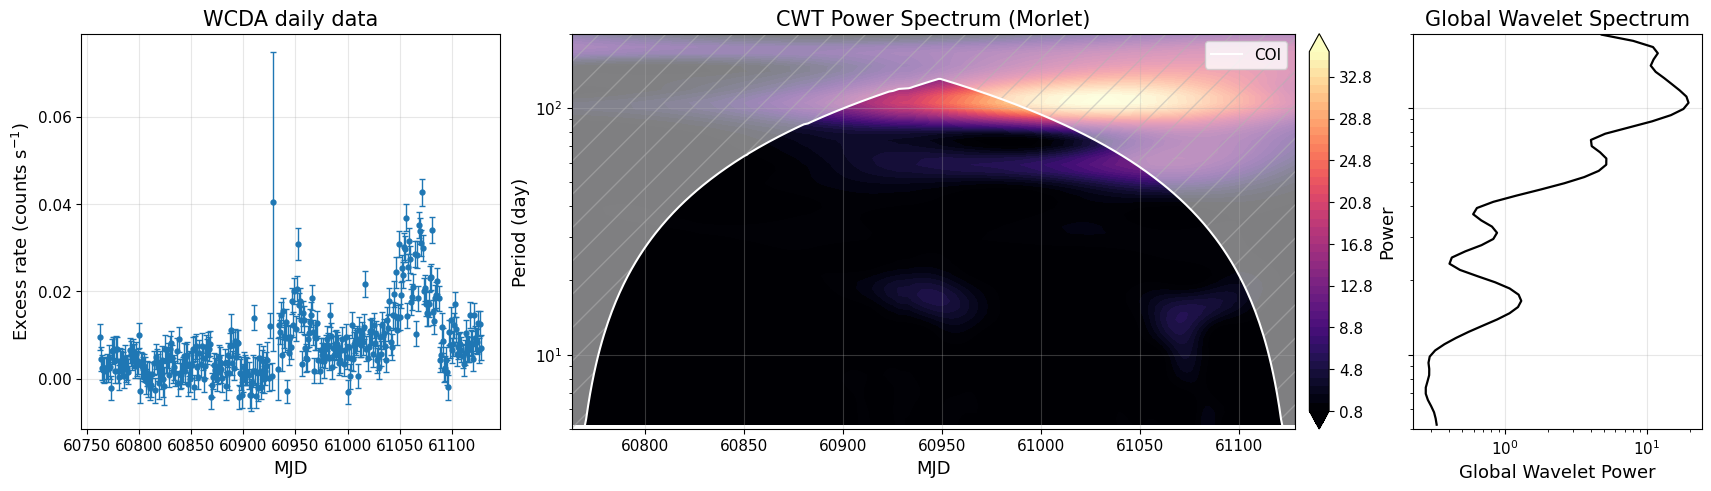

,period_day,power
0,104.950644,19.649791
1,166.598763,11.934181
2,62.404026,5.173945
3,16.528691,1.299636
4,31.202013,0.876558


In [6]:
wcda_cwt = run_cwt(t_wcda, flux_wcda, period_min=5.0, period_max=200.0)
fig, axes = plot_cwt_summary(
    t_wcda,
    flux_wcda,
    flux_err_wcda,
    wcda_cwt,
    lc_title='WCDA daily data',
    flux_label='Excess rate (counts s$^{-1}$)',
)
plt.show()

wcda_cwt_candidates = top_period_candidates(
    wcda_cwt['period'][wcda_cwt['mask_period']],
    wcda_cwt['gws'][wcda_cwt['mask_period']],
    topk=5,
)
wcda_cwt_candidates


## 6. WWZ 分析

WWZ 更适合不规则或带误差的观测序列，这里作为 CWT 的互证工具。
daily 数据仍使用同一套 `clean_and_merge_weighted` 逻辑，但周期范围切换为 **5–200 天**。


*** Starting Weighted Wavelet Z-transform ***

Pseudo sample frequency (median) is  1.0
largest tau window is  1.466
12.78 seconds has passed to complete Weighted Wavelet Z-transform 



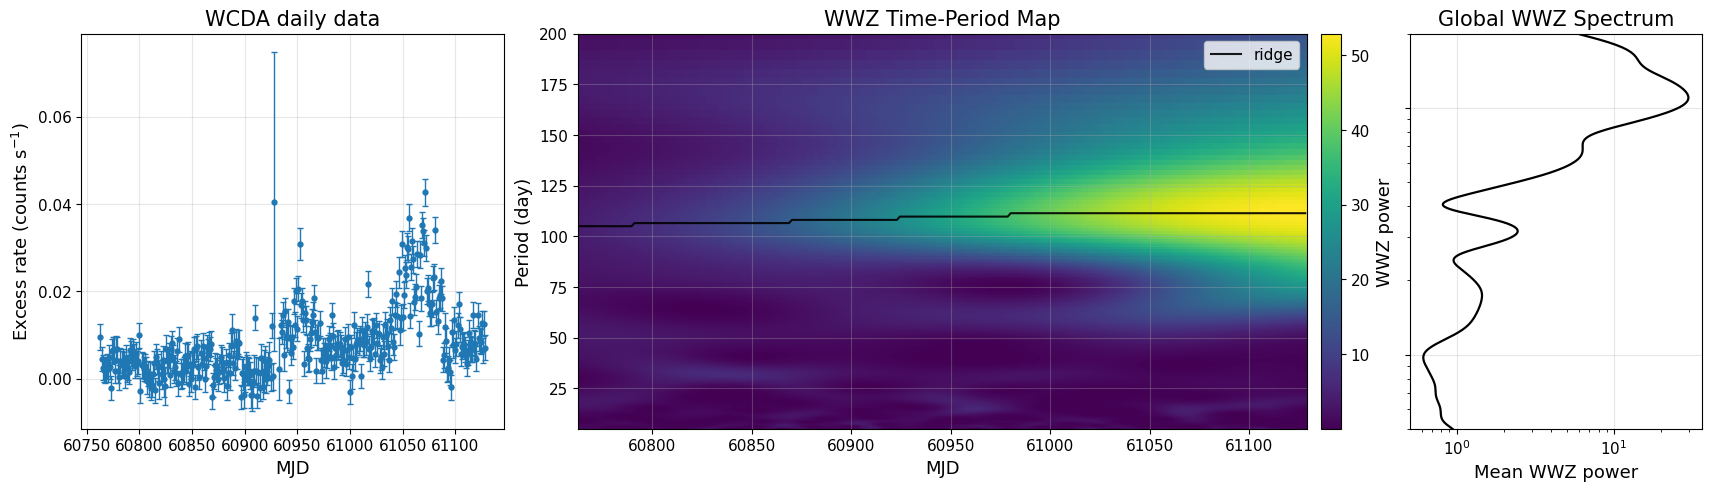

,period_day,power
0,109.774427,29.785728
1,67.906969,6.334514
2,31.670277,2.446351
3,17.360283,1.451392


In [7]:
wcda_wwz = run_wwz(
    t_wcda,
    flux_wcda,
    flux_err_wcda,
    period_min=5.0,
    period_max=200.0,
    time_divisions=250,
    decay_constant=0.0125,
)
fig, axes = plot_wwz_summary(
    wcda_wwz,
    lc_title='WCDA daily data',
    flux_label='Excess rate (counts s$^{-1}$)',
)
plt.show()

wcda_wwz_candidates = top_period_candidates(
    wcda_wwz['period_axis'],
    wcda_wwz['global_wwz'],
    topk=5,
)
wcda_wwz_candidates


## 7. 简要结果说明

- 这份 notebook 面向 daily 数据，重点看的是更短时间尺度上的候选时频结构。
- 预处理阶段实际排除了 6 个不可用 bin：3 个显式缺失日和 3 个 `tobs=0` 的零曝光 bin。
- 上面的 CWT / WWZ 候选周期表只用于给出“值得后续关注的尺度”，不是显著性结论。
- 当前 notebook **未进行模拟、显著性阈值、pre-trial / post-trial、Monte Carlo 或 Emmanoulopoulos 检验**。
